# Train on A and B separately, then test on combined dataset
### Train on dataset where A and B tokens appear in separate sequences (with null token), test on combined dataset where A and B appear in same sequence.

In [48]:
%load_ext autoreload
%autoreload 2  


In [49]:
import copy
import gc
from matplotlib import cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import os
import torch
from torch.utils.data import DataLoader, ConcatDataset
from torch import nn
from torch import optim
import sys

src_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
if src_path not in sys.path: sys.path.insert(0, src_path)

from analysis.utils import pca
from data.sequences import Sequences, Hypercube, SeqLengths, EmbedData
from data import utils as data_utils
from networks.models import AutoRNN
from networks import utils as network_utils
import plot_utils


In [50]:
plt.close('all')
gc.collect()

200

### Set reproducibility parameters

In [51]:
params = {
    'reproducibility' : {
        'torch_seed' : 7,
        'cuda_seed' : 7,
        'use_deterministic_algorithms' : False,
        'cudnn_deterministic' : False,
        'cudnn_benchmark' : True
    }
}

# Could also set seed for random module and numpy if needed.
torch.manual_seed(params['reproducibility']['torch_seed'])
torch.cuda.manual_seed(params['reproducibility']['cuda_seed'])

torch.use_deterministic_algorithms(params['reproducibility']['use_deterministic_algorithms'])
torch.backends.cudnn.deterministic = params['reproducibility']['cudnn_deterministic']
torch.backends.cudnn.benchmark = params['reproducibility']['cudnn_benchmark']


## Prepare data
### Set data parameters

In [52]:
# -----------------------------TRAINING DATA -------------------------------- #

# The 'data' dictionary, when all key-value pairs are set, will be passed to 
# the Sequences constructor method.
params.update({
    'data' : {
        'train' : {
            'dtype' : torch.int8,
            'num_vars' : 2
        }
    }
})

# Create SeqLengths object.
seq_lengths = SeqLengths(
    (torch.arange(10), data_utils.uniform_pmf(10), 'pos'),
    (torch.arange(5), data_utils.uniform_pmf(5), 'neg')
)

# Create Hypercube objects.
hypercube_A = Hypercube(
    num_dims=params['data']['train']['num_vars'],
    coords=torch.tensor([0, 1], dtype=torch.int64),
    inclusion_set=torch.tensor(
          [[0, 1], [1, 0]],
          dtype=torch.int8
    ),
    encoding=torch.tensor([0, 1], dtype=params['data']['train']['dtype']) # Sequences data attribute will ultimately be generated from copies of this tensor
)
hypercube_A.set_vertices_distrs(
    pmfs=(
        torch.tensor([1., 0.]), torch.tensor([1., 0.])
    )
    # pmfs=None
)

hypercube_B = copy.deepcopy(hypercube_A)
hypercube_B.set_vertices_distrs(
    pmfs=(
        torch.tensor([0., 1.]), torch.tensor([1., 0.])
    )
)

# Create transform object to embed hypercube in R^n.
transform = {
    'ambient_dim' : 5,
    'mean_center' : False,
    'offset_1' : -torch.tile(torch.tensor([0.5]), (params['data']['train']['num_vars'] + 3,)), # Plus 3 for the dimensions corresponding to special tokens
    'offset_2' : None,
    'method' : 'random_rotation',
    'noise' : {
        'distr' : torch.Tensor.normal_,
        'distr_params' : {
            'mean' : 0,
            'std' : 0.01
        }
    }
}
embedding = EmbedData(**transform)
if transform['ambient_dim'] < params['data']['train']['num_vars'] + 3:
    raise ValueError(
        "`ambient_dims` must be at least `num_vars` + 3 = " 
        f"{params['data']['train']['num_vars'] + 3}, but got {transform['ambient_dim']}."
    )

# Store helper objects for future reference.
params.update({
    'data_auxiliary' : {
        'train' : {
            'hypercube' : [hypercube_A, hypercube_B],
            'seq_lengths' : seq_lengths,
        }
    }
})

# Finish setting parameters.
params['data']['train'].update({
    'num_seq' : 1024,
    'len_distr' : seq_lengths.lengths,
    'seq_order' : 'permute',
    'transform' : embedding
})

# Sample sequences separately for each distribution over vertices.
sequences_A = Sequences(
    **{**params['data']['train'], 'elem_distr' : hypercube_A.vertices}
)
sequences_A.sample()
sequences_B = Sequences(
    **{**params['data']['train'], 'elem_distr' : hypercube_B.vertices}
)
sequences_B.sample()

# Update dictionary to store 'elem_distr'.
params['data']['train'].update({'elem_distr' : [hypercube_A.vertices, hypercube_B.vertices]})

sequences = dict()

# XXX: Combine two sequences objects into one. This is not a good solution,
# since the resultant object is not truly designed to be a mix but is a quick
# and dirty way of doing things. In particular, attributes may not be accurate.
sequences['train'] = copy.deepcopy(sequences_A)
sequences['train'].data = sequences['train'].data + sequences_B.data
sequences['train'].labels = sequences['train'].labels + sequences_B.labels
for class_ in ['pos', 'neg']:
    sequences['train'].seq_elems[class_].extend(sequences_B.seq_elems[class_])
    sequences['train'].seq_lens[class_] = torch.cat(
        (sequences['train'].seq_lens[class_], sequences_B.seq_lens[class_])
    )
    sequences['train'].within_class_labels[class_].extend(
        sequences_B.within_class_labels[class_]
    )
    # sequences['train'].seq_elems[class_] = (
    #     sequences['train'].seq_elems[class_] + sequences_B.seq_elems[class_]
    # )
    # sequences['train'].seq_lens[class_] = (
    #     sequences['train'].seq_lens[class_] + sequences_B.seq_lens[class_]
    # )
    # sequences['train'].within_class_labels[class_] = (
    #     sequences['train'].within_class_labels[class_] + sequences_B.within_class_labels[class_]
    # )

# Twice as many sequences.
sequences['train'].num_seq *= 2

# The data were sampled from two separate distributions, so cause exception
# to be raised if access to this attribute is attempted.
delattr(sequences['train'], 'elem_distr')

sequences['train'].add_special_tokens()


In [53]:
# ------------------------------TESTING DATA -------------------------------- #
MODIFY_TRAIN_DATA_PARAMS = True
if MODIFY_TRAIN_DATA_PARAMS:
    # Create SeqLengths object.
    seq_lengths = SeqLengths(
        (torch.tensor([5, 7, 9]), data_utils.uniform_pmf(3), 'pos'),
        (torch.tensor([2, 3]), data_utils.uniform_pmf(2), 'neg')
    )

    # Create Hypercube object.
    hypercube = Hypercube(
        num_dims=params['data']['train']['num_vars'],
        coords=torch.tensor([0, 1], dtype=torch.int64),
        inclusion_set=torch.tensor(
            [[0, 1], [1, 0]],
            dtype=torch.int8
        ),
        encoding=torch.tensor([0, 1], dtype=params['data']['train']['dtype']) # Sequences data attribute will ultimately be generated from copies of this tensor
    )
    hypercube.set_vertices_distrs(
        pmfs=(
            torch.tensor([0.5, 0.5]), torch.tensor([1., 0.])
        )
        # pmfs=None
    )

    # Store helper objects for future reference.
    params.update({
        'data_auxiliary' : {
            'test' : {
                'hypercube' : hypercube,
                'seq_lengths' : seq_lengths,
            }
        }
    })
    # Create modified dictionary for testing.
    params['data']['test'] = {
        **params['data']['train'], 
        **{
            'num_seq' : 512, 
            'len_distr': seq_lengths.lengths, 
            'elem_distr' : hypercube.vertices
        }
    }
else:
    # Manually set all test parameters here.
    pass
    
# Sample new sequences for testing according to specified distributions.
sequences['test'] = Sequences(**params['data']['test'])
sequences['test'].sample()
sequences['test'].add_special_tokens()

### Visualize sequence data

In [54]:
# To get interactive plots, do the following: install ipympl package and
# restart VS code. Then, run either %matplotlib widget or %matplotlib ipympl in 
# the notebook.
%matplotlib widget

Shape of single sequence: torch.Size([15, 5]).
Shape of corresponding labels: torch.Size([15]).
Sequence: 
 tensor([[-0.0568,  0.3146, -0.6722, -0.4352, -0.6911],
        [-0.3233, -0.5004,  0.1178,  0.3334, -0.8841],
        [-0.1444, -0.8727, -0.2768,  0.6205, -0.1227],
        [-0.1567, -0.8920, -0.3127,  0.6108, -0.1448],
        [-0.3297, -0.4965,  0.1201,  0.3213, -0.9007],
        [-0.3355, -0.4742,  0.1182,  0.3293, -0.8984],
        [-0.1365, -0.8633, -0.3044,  0.5974, -0.1109],
        [-0.1327, -0.8536, -0.2925,  0.6074, -0.1317],
        [-0.3163, -0.4852,  0.1221,  0.3216, -0.8736],
        [ 0.6808,  0.6606, -0.1652, -0.3001, -0.4665],
        [-0.3952,  0.3571, -0.4046,  0.4554, -0.7893],
        [-0.3859,  0.3527, -0.4071,  0.4461, -0.7958],
        [-0.3922,  0.3540, -0.4094,  0.4572, -0.7911],
        [-0.3954,  0.3538, -0.4055,  0.4548, -0.7777],
        [ 0.3538,  0.6778,  0.1271,  0.5859, -0.5609]]).
Labels by class: 
 tensor([ 2, -1,  4,  4, -1, -1,  4,  4, -1,  3

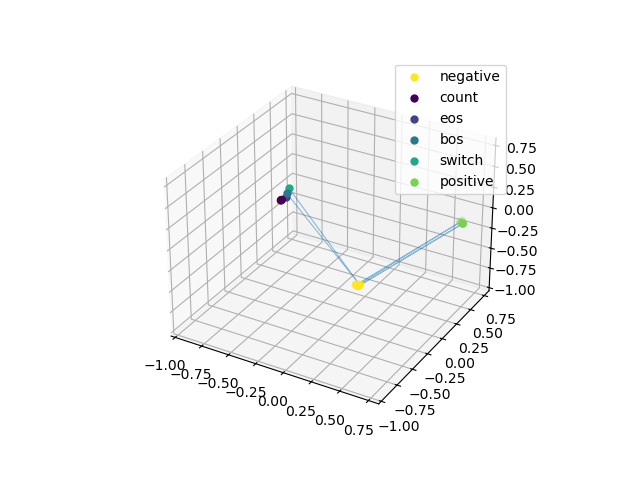

In [55]:
# Get one sequence.
seq_idx = 10

# Visualize transformed vs untransformed data.
if True:
    seq, labels, _, _, _ = sequences['train'][seq_idx]
    
    # Get version where all labels in positive vs negative class to be the same.
    labels_uniform_class = labels.clone()
    labels_uniform_class[labels >= 4] = 4
    labels_uniform_class[labels < 0] = -1
else:
    seq = sequences['train'].data[seq_idx]
    labels = sequences['train'].labels[seq_idx]

print(f"Shape of single sequence: {seq.shape}.")
print(f"Shape of corresponding labels: {labels.shape}.")
print(f"Sequence: \n {seq}.") 
print(f"Labels by class: \n {labels_uniform_class}.") 
print(f"Labels by stimulus: \n {labels}.") 

pcs = pca(seq, num_comps=3)[0]

# Prepare for plotting.
color_range = (0., 1.)
colors = cm.viridis(torch.linspace(color_range[0], color_range[1], 6)) 

# This dictionary will be passed to plotting function and contains plotting 
# information for each label.
labels_dict = {
    int(token_info['label']) : {
        'label' : token_name, 
        'color' : colors[i_token] 
    }
    for i_token, (token_name, token_info) in enumerate(sequences['train'].special_tokens.items())
}
labels_dict.update({
    4 : {
        'label' : 'positive',
        'color' : colors[4]
    },
    -1 : {
        'label' : 'negative',
        'color' : colors[5]
    }
})

# Plot sequence's timepoints, color labeled by class class membership.
fig_1 = plt.figure()
ax_1 = fig_1.add_subplot(projection='3d')
_, ax = plot_utils.plot_labeled_points(pcs, labels_uniform_class, labels_dict, ax=ax_1)

# Plot trajectory linking sequence points.
if True: ax.plot(pcs[:, 0], pcs[:, 1], pcs[:, 2], alpha=0.5, linewidth=0.75)

# Normalize axis limits.
if True:
    vmin = torch.min(pcs)
    vmax = torch.max(pcs)
    axis_limits = [vmin, vmax]
    ax_1.set_xlim(axis_limits)
    ax_1.set_ylim(axis_limits)
    ax_1.set_zlim(axis_limits)


## Train and test model

In [56]:
local_device = torch.device(
    'cuda' if torch.cuda.is_available() 
    else 'mps:0' if torch.backends.mps.is_available() 
    else 'cpu'
)

### Set model parameters and instantiate

In [57]:
rnn_type = nn.GRU

INPUT_TRANSFORM = False
if INPUT_TRANSFORM:
    input_network_config = {
        'layer_sizes' : [transform['ambient_dim'], 50],
        'nonlinearities' : [nn.ReLU()],
        'dropouts' : [None]
    }
    rnn_input_size = input_network_config['layer_sizes'][-1]
else:
    input_network_config = {
        'layer_sizes' : None
    }
    rnn_input_size = transform['ambient_dim']

rnn_config = {
    'input_size' : rnn_input_size,
    'hidden_size' : 20,
    'num_layers' : 1,
    'bias' : True,
    'batch_first' : True,
    'bidirectional' : False,
    'device' : None
}
if rnn_type is nn.RNN: rnn_config.update({'nonlinearity' : 'tanh'}) # Set nonlinearity if RNN

readout_network_config = {
    'layer_sizes' : [rnn_config['hidden_size'], 80, 2],
    'nonlinearities' : [nn.GELU(), None],
    'dropouts' : [nn.Dropout(p=0.5), None]
}

params.update({
    'model' : {
        'input_network_config' : input_network_config,
        'rnn_config' : rnn_config,
        'readout_network_config' : readout_network_config
    }
})

model = AutoRNN(
    params['model']['input_network_config'],
    params['model']['rnn_config'],
    params['model']['readout_network_config'],
    rnn_type=rnn_type,
    tokens=sequences['train'].transform(
        torch.cat(
            (sequences['train'].special_tokens['count']['token'].unsqueeze(0), 
            sequences['train'].special_tokens['eos']['token'].unsqueeze(0)), 
            dim=0
        )
    ).to(local_device)
)

In [58]:
# rnn_type = nn.GRU
# INPUT_TRANSFORM = True

# if INPUT_TRANSFORM:
#     input_network_config = {
#         'layer_sizes' : [transform['ambient_dim'], 50],
#         'nonlinearities' : [nn.ReLU()],
#         'dropouts' : [None]
#     }
#     rnn_input_size = input_network_config['layer_sizes'][-1]
# else:
#     input_network_config = None
#     rnn_input_size = transform['ambient_dim']

# rnn_config = {
#     'input_size' : rnn_input_size,
#     'hidden_size' : 20,
#     'num_layers' : 1,
#     'bias' : True,
#     'batch_first' : True,
#     'bidirectional' : False,
#     'device' : None
# }
# if rnn_type is nn.RNN: rnn_config.update({'nonlinearity' : 'tanh'}) # Set nonlinearity if RNN

# readout_network_config = {
#     'layer_sizes' : [rnn_config['hidden_size'], 80, 2],
#     'nonlinearities' : [nn.GELU(), None],
#     'dropouts' : [nn.Dropout(p=0.5), None]
# }

# params.update({
#     'model' : {
#         'input_network_config' : input_network_config,
#         'rnn_config' : rnn_config,
#         'readout_network_config' : readout_network_config
#     }
# })

# model = AutoRNN(
#     params['model']['input_network_config'],
#     params['model']['rnn_config'],
#     params['model']['readout_network_config'],
#     rnn_type=rnn_type,
#     tokens=sequences['train'].transform(
#         torch.cat(
#             (sequences['train'].special_tokens['count']['token'].unsqueeze(0), 
#             sequences['train'].special_tokens['eos']['token'].unsqueeze(0)), 
#             dim=0
#         )
#     ).to(local_device)
# )

### Train model

In [59]:
dataloaders = dict()
dataloaders['train'] = DataLoader(
    sequences['train'], 
    batch_size=128, 
    shuffle=True, 
    collate_fn=sequences['train'].pad_collate_fn
)

params.update({
    'train' : {
        'dataloader' : dataloaders['train'],
        'optimizer' : optim.Adam(model.parameters(), lr=0.001),
        'loss_fn' : nn.CrossEntropyLoss(),
        'h_0' : None,
        'deterministic' : True,
        # 'early_stopping_params' : {
        #     'delta' : 5,
        #     'epsilon' : -1e-6,
        #     'criterion' : lambda x : torch.mean(torch.diff(x, n=1))
        # },
        'early_stopping_params' : None,
        'num_epochs' : 200,
        'device' : local_device,
        'pack' : True,
    }
})

training = network_utils.train(model, **params['train'])


Mean batch loss for epoch 0: 0.6505130529403687.
Mean batch accuracy for epoch 0: 0.04833984375.
Mean batch loss for epoch 1: 0.536389172077179.
Mean batch accuracy for epoch 1: 0.0.
Mean batch loss for epoch 2: 0.48531538248062134.
Mean batch accuracy for epoch 2: 0.0.
Mean batch loss for epoch 3: 0.47487613558769226.
Mean batch accuracy for epoch 3: 0.0.
Mean batch loss for epoch 4: 0.462084025144577.
Mean batch accuracy for epoch 4: 0.0.
Mean batch loss for epoch 5: 0.4419911205768585.
Mean batch accuracy for epoch 5: 0.0.
Mean batch loss for epoch 6: 0.40001821517944336.
Mean batch accuracy for epoch 6: 0.0.
Mean batch loss for epoch 7: 0.31751206517219543.
Mean batch accuracy for epoch 7: 0.09130859375.
Mean batch loss for epoch 8: 0.23471462726593018.
Mean batch accuracy for epoch 8: 0.4111328125.
Mean batch loss for epoch 9: 0.1979655772447586.
Mean batch accuracy for epoch 9: 0.4814453125.
Mean batch loss for epoch 10: 0.16325701773166656.
Mean batch accuracy for epoch 10: 0.59

### Visualize training results

/Users/jonathan/miniconda3/envs/counting_rnn/lib/python3.10/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1729647065806/work/aten/src/ATen/native/TensorShape.cpp:3596.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


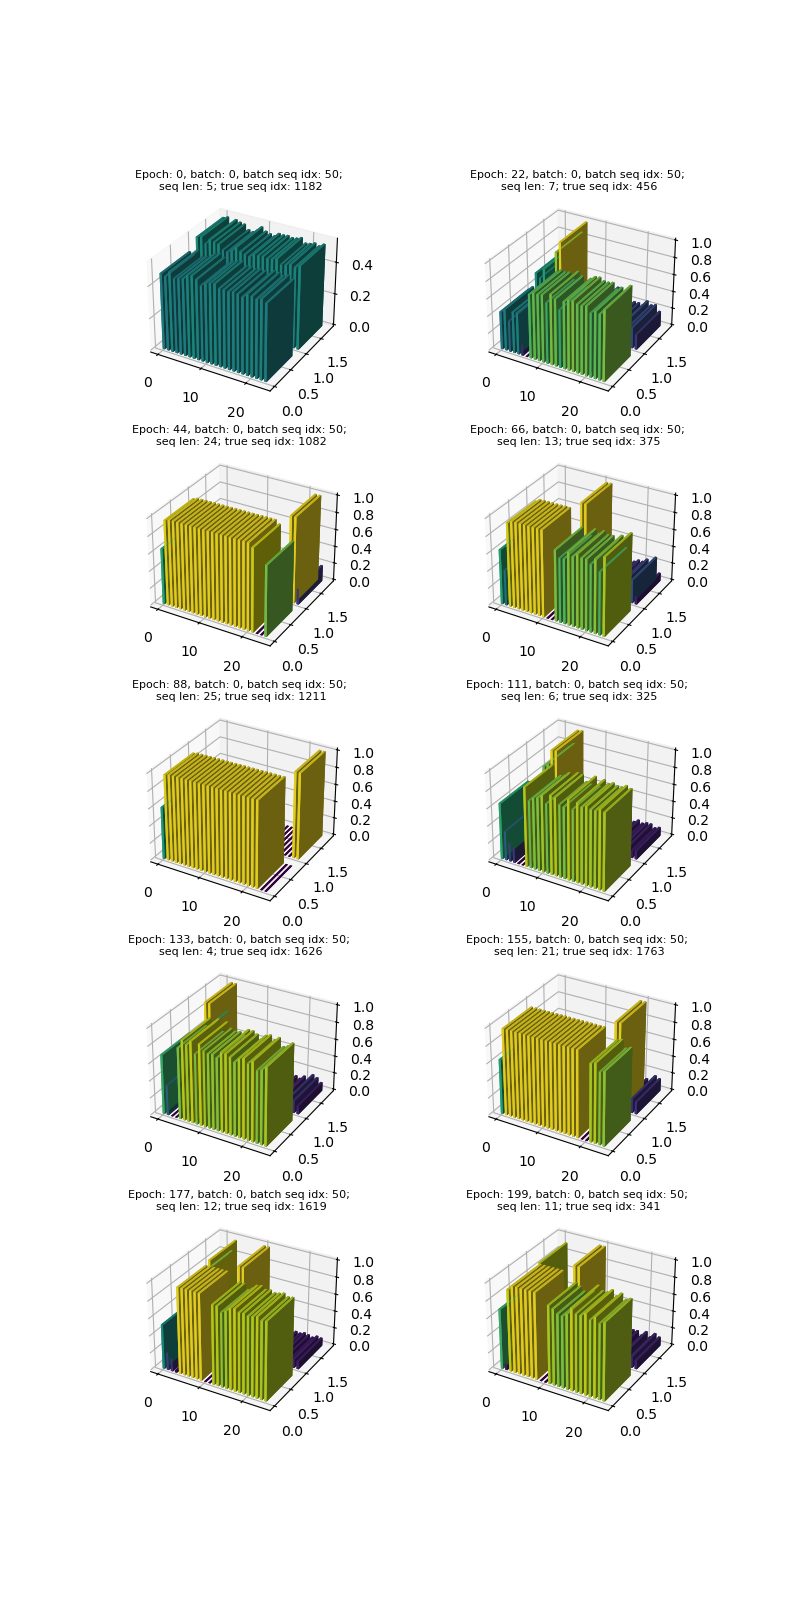

In [60]:
# Track model outputs during training.
num_seqs_to_plot = 10
epoch_ind = torch.round(torch.linspace(0, params['train']['num_epochs']-1, num_seqs_to_plot)).to(torch.int64)
batch_idx = 0
batch_seq_idx = 50

fig_2, axs_2 = plt.subplots(
    (num_seqs_to_plot+1)//2, 2, subplot_kw={'projection' : '3d'}, figsize=(8, 16)
)
axs_2 = np.atleast_2d(axs_2)

for i_subplot, i_epoch in enumerate(epoch_ind):
    # Additional info.
    seq_len = training['lengths'][i_epoch][batch_idx][batch_seq_idx]
    true_seq_idx = training['seq_ind'][i_epoch][batch_idx][batch_seq_idx]

    i_row, i_col = divmod(i_subplot, 2)

    _, axs_2[i_row, i_col] = plot_utils.plot_softmax(
        training['logits'][i_epoch][batch_idx][batch_seq_idx, :, :],
        ax=axs_2[i_row, i_col]
    )
    
    axs_2[i_row, i_col].set_title(
        f"Epoch: {i_epoch}, batch: {batch_idx}, batch seq idx: {batch_seq_idx}; " 
        f"\nseq len: {seq_len}; true seq idx: {true_seq_idx}", 
        fontsize=8,
        pad=0.1
    )


torch.Size([128, 25, 20])
tensor([ 2,  4, -1,  4,  4,  4,  3,  0,  0,  0,  0,  1])


Text(0.5, 0, 'PC 3')

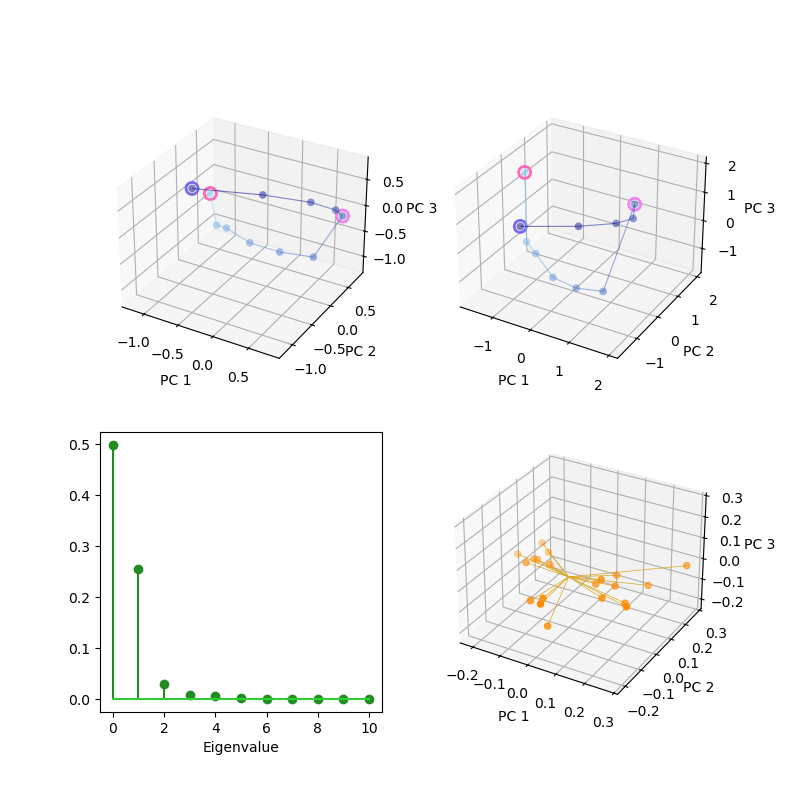

In [61]:
# Here, looking at sequences during training.
epoch_idx = params['train']['num_epochs']-1
batch_idx = 7
batch_seq_idx = 10 # This is within batch, not original seq_idx

# Get hidden states during training and perform PCA.
seq_len = training['lengths'][epoch_idx][batch_idx][batch_seq_idx]
print(training['hidden'][epoch_idx][batch_idx].shape)
hidden_train = training['hidden'][epoch_idx][batch_idx][batch_seq_idx, :seq_len-1, :] # Minus so that last timepoint is the one on which EOS is output/"predicted"
train_pcs, train_eigs, train_loadings, train_eigenvecs, train_eigenspectrum \
    = pca(hidden_train, 3)

# Get true sequence index.
true_seq_idx = training['seq_ind'][epoch_idx][batch_idx][batch_seq_idx].item()

# Get BOS, switch, and EOS token positions.
labels = sequences['train'].labels[true_seq_idx]
print(labels)
ind = {
    token : torch.where(labels == sequences['train'].special_tokens[token]['label'])[0]
    for token in ['bos', 'switch', 'eos']
}
ind['eos'] -= 1 # We want the timepoint at which EOS was output ("predicted"), not the timepoint at which it appears in ground truth labels
colors = ['hotpink', 'violet', 'mediumslateblue']

# Plotting ---------------------------------------------
fig_4, axs_4 = plt.subplots(2, 2, figsize=(8, 8))

# PCs for training hidden states.
for k in [0, 1]:
    axs_4[0, k].remove()
    axs_4[0, k] = fig_4.add_subplot(2, 2, k+1, projection='3d')

    # Plot trajectory.
    if k == 1: train_pcs = train_pcs / torch.sqrt(train_eigs)
    _, axs_4[0, k] = plot_utils.plot_trajectory(
        train_pcs, 
        ax=axs_4[0, k],
        traj_linewidth=0.8,
        marker_size=30,
        alpha=0.5,
        set_box_aspect=False,
        uniform_axis_size=True
    )
    for i_token, (key, value) in enumerate(ind.items()):
        axs_4[0, k].scatter(
            train_pcs[value, 0], train_pcs[value, 1], train_pcs[value, 2], 
            color=colors[i_token],
            marker='o',
            facecolors='none',
            s=75,
            linewidths=2,
        )
    axs_4[0, k].set_xlabel('PC 1')
    axs_4[0, k].set_ylabel('PC 2')
    axs_4[0, k].set_zlabel('PC 3')

# Plot eigenspectrum.
axs_4[1, 0].remove()
axs_4[1, 0] = fig_4.add_subplot(2, 2, 3)
axs_4[1, 0].stem(
    train_eigenspectrum,
    linefmt='forestgreen',
    markerfmt='forestgreen',
    basefmt='limegreen'
)
axs_4[1, 0].set_xlabel('Eigenvalue')

# Plot loadings (with variance).
axs_4[1, 1].remove()
axs_4[1, 1] = fig_4.add_subplot(2, 2, 4, projection='3d')
axs_4[1, 1].scatter(
    train_loadings[:, 0], train_loadings[:, 1], train_loadings[:, 2],
    color='darkorange'
)
for i_neuron in range(train_loadings.shape[0]):
    axs_4[1, 1].plot(
        [0, train_loadings[i_neuron, 0]], 
        [0, train_loadings[i_neuron, 1]], 
        [0, train_loadings[i_neuron, 2]],
        linewidth=0.5, alpha=1.0, color='goldenrod'
    )
axs_4[1, 1].set_xlim([train_loadings.min(), train_loadings.max()])
axs_4[1, 1].set_ylim([train_loadings.min(), train_loadings.max()])
axs_4[1, 1].set_zlim([train_loadings.min(), train_loadings.max()])
axs_4[1, 1].set_xlabel('PC 1')
axs_4[1, 1].set_ylabel('PC 2')
axs_4[1, 1].set_zlabel('PC 3')

### Test model

In [62]:
# Dataset to use for testing (can use train set for debugging).
test_on = 'test'

# Prepare test dataloader. 
dataloaders['test'] = DataLoader(
    sequences[test_on],
    batch_size = min(params['data'][test_on]['num_seq'], 1024),
    shuffle=False,
    collate_fn=sequences['test'].pad_collate_fn
)

# Prepare parameters for test function.
params.update({
    'test' : {
        'dataloader' : dataloaders['test'],
        'switch_label' : sequences[test_on].special_tokens['switch']['label'],
        'loss_fn' : nn.CrossEntropyLoss(),
        'h_0' : None,
        'deterministic' : True, # Control whether next token during autoregressive generation is selected deterministically via argmax or probabilistically via softmax and sampling
        'device' : torch.device(
            'cuda' if torch.cuda.is_available() 
            else 'mps' if torch.backends.mps.is_available() 
            else 'cpu'
        ),
        'criteria' : [network_utils.calculate_prop_correct],
    }
})

testing = network_utils.test(model, **params['test'])

batch_idx = 0
criterion_idx = 0
print(
    f"Test loss on test batch {batch_idx+1} of {len(testing['performance'])}: {testing['mean_loss']}, " 
    f"test accuracy: {testing['performance'][batch_idx][criterion_idx][0]}."
)

Test loss on test batch 1 of 1: 4.465342044568388e-06, test accuracy: 1.0.


### Visualize output of network on test set

Labels for plot 0 (batch seq idx : 0, true seq idx : 0): 
tensor([ 2,  5,  5,  4,  4, -1,  5, -1,  4, -1,  5,  3,  0,  0,  0,  0,  0,  0,
         0,  1]).
Labels for plot 1 (batch seq idx : 128, true seq idx : 128): 
tensor([ 2,  4,  5,  5,  5,  4, -1, -1, -1,  5,  5,  3,  0,  0,  0,  0,  0,  0,
         0,  1]).
Labels for plot 2 (batch seq idx : 256, true seq idx : 256): 
tensor([ 2,  4,  4,  4, -1, -1,  5, -1,  5,  3,  0,  0,  0,  0,  0,  1]).
Labels for plot 3 (batch seq idx : 383, true seq idx : 383): 
tensor([ 2, -1,  5, -1,  5, -1,  4,  5,  5,  3,  0,  0,  0,  0,  0,  1]).
Labels for plot 4 (batch seq idx : 511, true seq idx : 511): 
tensor([ 2, -1,  4,  5, -1,  5,  4,  4,  5,  4, -1,  3,  0,  0,  0,  0,  0,  0,
         0,  1]).


Text(0.5, 0.98, 'Network performance on random subset of test sequences')

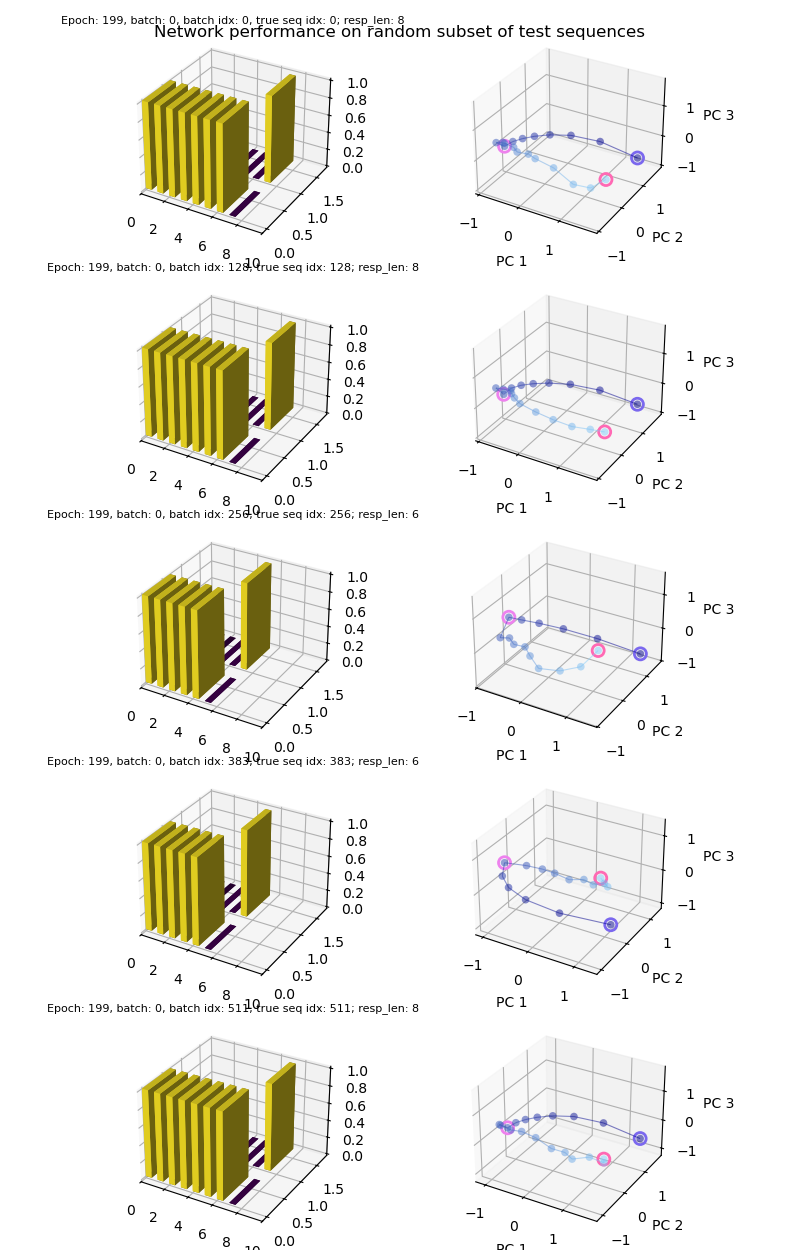

In [63]:
# Usually the whole test set will be fed as one batch if it's not too large.
batch_idx = 0

# # Join input demonstration phase and generated response hidden states for all sequences.
# hidden_test, hidden_test_lengths = network_utils.join_demo_gen_resp(
#     testing['on_input'][batch_idx]['hidden'],
#     testing['on_input'][batch_idx]['input_lengths']-1, # -1 to exclude switch index, which will be included in the generated response
#     testing['generated'][batch_idx]['hidden'],
#     testing['generated'][batch_idx]['resp_lengths'],
# )
hidden_test, hidden_test_lengths = testing['joined'][batch_idx]['hidden']

# Visualize logit output on random subset of test set.
num_seqs_to_plot = 5
seq_ind_to_plot = torch.round(
    torch.linspace(0, params['test']['dataloader'].batch_size-1, num_seqs_to_plot)
).to(torch.int64)

fig_3, axs_3 = plt.subplots(
    num_seqs_to_plot, 2, 
    subplot_kw={'projection' : '3d'}, 
    figsize=(8, 2.5 * num_seqs_to_plot), 
    squeeze=False
)

for i_idx, batch_seq_idx in enumerate(seq_ind_to_plot):
    # Get additional variables.
    resp_len = testing['generated'][batch_idx]['resp_lengths'][batch_seq_idx]
    true_seq_idx = testing['seq_ind'][batch_idx][batch_seq_idx]

    # ---------------------------- Plot logits ------------------------------ #
    _, axs_3[i_idx, 0] = plot_utils.plot_softmax(
        testing['generated'][batch_idx]['logits'][batch_seq_idx, :resp_len, :],
        ax=axs_3[i_idx, 0],
        depth=0.7
    )
    axs_3[i_idx, 0].set_title(
        f"Epoch: {i_epoch}, batch: {batch_idx}, batch idx: {batch_seq_idx}, " 
        f"true seq idx: {true_seq_idx}; resp_len: {resp_len}", 
        fontsize=8
    )
    axs_3[i_idx, 0].set_xlim([0, testing['generated'][batch_idx]['logits'].shape[1]])

    # ---------------------------- Plot trajectory -------------------------- #
    # Get BOS, switch, and EOS token positions.
    labels_test = sequences['test'].labels[true_seq_idx]
    ind = {
    token : torch.where(labels_test == sequences['test'].special_tokens[token]['label'])[0]
    for token in ['bos', 'switch', 'eos']
    }
    ind['eos'] -= 1 # We want the timepoint at which EOS was output ("predicted"), not the timepoint at which it appears in ground truth labels
    
    # PCA.
    test_pcs = pca(
        hidden_test[batch_seq_idx, :hidden_test_lengths[batch_seq_idx], :], 
        num_comps=3
    )[0]

    # Plot trajectory.
    _, axs_3[i_idx, 1] = plot_utils.plot_trajectory(
            test_pcs, 
            ax=axs_3[i_idx, 1],
            traj_linewidth=0.8,
            marker_size=30,
            alpha=0.5,
            set_box_aspect=False,
            uniform_axis_size=True
        )
    
    # Plot markers for special tokens.
    for i_token, (key, value) in enumerate(ind.items()):
        axs_3[i_idx, 1].scatter(
            test_pcs[value, 0], test_pcs[value, 1], test_pcs[value, 2], 
            color=colors[i_token],
            marker='o',
            facecolors='none',
            s=75,
            linewidths=2,
        )

    # Print correct labels.
    print(
        f"Labels for plot {i_idx} (batch seq idx : {batch_seq_idx}, " 
        f"true seq idx : {true_seq_idx}): \n{sequences['test'].labels[true_seq_idx]}."
    )
        
    axs_3[i_idx, 1].set_xlabel('PC 1')
    axs_3[i_idx, 1].set_ylabel('PC 2')
    axs_3[i_idx, 1].set_zlabel('PC 3')
    
    
fig_3.tight_layout()    
fig_3.suptitle("Network performance on random subset of test sequences")


In [64]:
# Usually the whole test set will be fed as one batch if it's not too large.
batch_idx = 0
criterion_idx = 0

# Join input demonstration phase and generated response hidden states for all sequences.
# hidden_test, hidden_test_lengths = network_utils.join_demo_gen_resp(
#     testing['on_input'][batch_idx]['hidden'],
#     testing['on_input'][batch_idx]['input_lengths']-1, # -1 to exclude switch index, which will be included in the generated response
#     testing['generated'][batch_idx]['hidden'],
#     testing['generated'][batch_idx]['resp_lengths'],
# )
hidden_test, hidden_test_lengths = testing['joined'][batch_idx]['hidden']

# Identify any sequences on which mistakes were made.
incorrect_ind = testing['performance'][batch_idx][criterion_idx][4]
if torch.numel(incorrect_ind) > 0:
    num_incorrect = len(incorrect_ind)
    print(num_incorrect)

    # Prepare for plotting.
    num_seqs_to_plot = min(8, num_incorrect) 
    seq_ind_to_plot = incorrect_ind[:num_seqs_to_plot]
    fig_5, axs_5 = plt.subplots(
        num_seqs_to_plot, 2, 
        figsize=(8, 2.5 * num_seqs_to_plot), 
        subplot_kw={'projection' : '3d'}, 
        squeeze=False
    )
    colors = ['hotpink', 'violet', 'mediumslateblue'] # For marking special tokens in trajectory plot


    for i_idx, batch_seq_idx in enumerate(seq_ind_to_plot):
        # First need to get true sequence index.
        true_seq_idx = testing['seq_ind'][batch_idx][batch_seq_idx]

        # -------------------------- Logits plot ---------------------------- #
        # Length of generated output for current sequence.
        resp_len = testing['generated'][batch_idx]['resp_lengths'][batch_seq_idx]

        # Plot logits for generated response.
        _, axs_5[i_idx, 0] = plot_utils.plot_softmax(
            testing['generated'][batch_idx]['logits'][batch_seq_idx, :resp_len, :],
            ax=axs_5[i_idx, 0],
            depth=0.7
        )

        # softmax = nn.Softmax(dim=-1)
        # print(softmax(testing['generated'][batch_idx]['logits'][batch_seq_idx, :resp_len, :]))

        axs_5[i_idx, 0].set_title(f"true seq idx: {true_seq_idx}")

        # ------------------------- Trajectory plot ------------------------- #
        # Get BOS, switch, and EOS token positions.
        labels_test = sequences['test'].labels[true_seq_idx]
        ind = {
        token : torch.where(labels_test == sequences['test'].special_tokens[token]['label'])[0]
        for token in ['bos', 'switch', 'eos']
        }
        ind['eos'] -= 1 # We want the timepoint at which EOS was output ("predicted"), not the timepoint at which it appears in ground truth labels
        
        # PCA.
        test_pcs_incorrect = pca(
            hidden_test[batch_seq_idx, :hidden_test_lengths[batch_seq_idx], :], 
            num_comps=3
        )[0]

        # Plot trajectory.
        _, axs_5[i_idx, 1] = plot_utils.plot_trajectory(
                test_pcs_incorrect, 
                ax=axs_5[i_idx, 1],
                traj_linewidth=0.8,
                marker_size=30,
                alpha=0.5,
                set_box_aspect=False,
                uniform_axis_size=True
            )
        
        # Plot markers for special tokens.
        for i_token, (key, value) in enumerate(ind.items()):
            axs_5[i_idx, 1].scatter(
                test_pcs_incorrect[value, 0], 
                test_pcs_incorrect[value, 1], 
                test_pcs_incorrect[value, 2], 
                color=colors[i_token],
                marker='o',
                facecolors='none',
                s=75,
                linewidths=2,
            )

        axs_5[i_idx, 1].set_xlabel('PC 1')
        axs_5[i_idx, 1].set_ylabel('PC 2')
        axs_5[i_idx, 1].set_zlabel('PC 3')

        # Print correct labels.
        print(
            f"Labels for plot {i_idx} (batch seq idx : {batch_seq_idx}, " 
            f"true seq idx : {true_seq_idx}): \n{sequences['test'].labels[true_seq_idx]}."
        )
        
    fig_5.tight_layout()    





In [65]:
seq, labels, _, _, _ = sequences['test'][28]

seq = seq.to(local_device)
switch_ind = torch.where(labels == 3)[0]

print(labels)
print(sequences['test'].labels[28])

# a = model(seq)
# print(a[1])

generated, on_input, joined = model.generate(seq, input_lengths=None, resp_lengths=seq.shape[0] - switch_ind - 1)

print(generated['labels'])

softmax = nn.Softmax(dim=-1)
print(softmax(generated['logits']))

print(testing['generated'][0]['labels'][28])
print(softmax(testing['generated'][0]['logits'][28]))

tensor([ 2,  5, -1,  5,  5,  5,  4, -1,  3,  0,  0,  0,  0,  0,  1])
tensor([ 2,  5, -1,  5,  5,  5,  4, -1,  3,  0,  0,  0,  0,  0,  1])
tensor([[1, 1, 1, 1, 1, 1]], device='mps:0')
tensor([[[4.1167e-16, 1.0000e+00],
         [1.4287e-18, 1.0000e+00],
         [5.7942e-19, 1.0000e+00],
         [6.9707e-19, 1.0000e+00],
         [9.3024e-19, 1.0000e+00],
         [1.1398e-18, 1.0000e+00]]], device='mps:0',
       grad_fn=<SoftmaxBackward0>)
tensor([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])
tensor([[1.0000e+00, 7.7441e-22],
        [1.0000e+00, 5.5888e-21],
        [1.0000e+00, 6.5743e-19],
        [1.0000e+00, 3.5382e-15],
        [1.0000e+00, 1.3897e-07],
        [1.5462e-07, 1.0000e+00],
        [9.2844e-16, 1.0000e+00],
        [1.7983e-18, 1.0000e+00],
        [5.8730e-19, 1.0000e+00],
        [6.7260e-19, 1.0000e+00]])


torch.Size([4890, 20])
torch.Size([4890, 20])


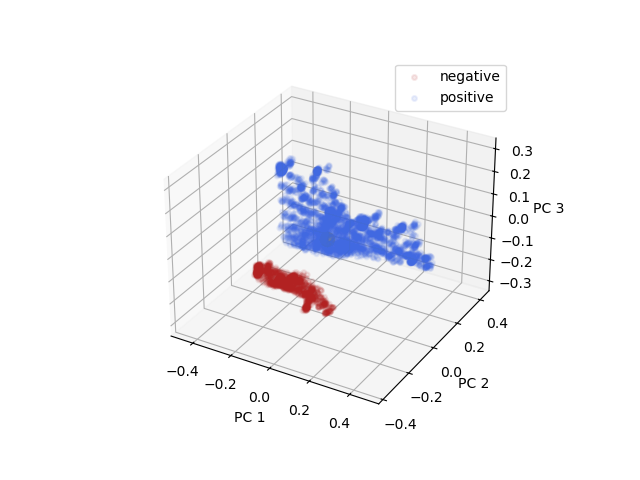

In [66]:
batch_idx = 0

# If there were incorrect sequences, can choose to exclude them.
exclude_incorrect = True
correct_ind = testing['performance'][batch_idx][criterion_idx][3]

# Get input phase for each sequence.
batch_size = len(testing['on_input'][batch_idx]['hidden'])
hidden_diff = []
diff_labels = []
for i_seq in range(batch_size):
    if not (exclude_incorrect and i_seq in incorrect_ind):
        # Get data from current sequence.
        hidden_diff.append(
            torch.diff(
                testing['on_input'][batch_idx]['hidden'][ 
                    i_seq, :testing['on_input'][batch_idx]['input_lengths'][i_seq]-1, : # -1 excludes switch token diff vector
                ],
                n=1,
                dim=0
            )
        )

        # Get labels from current sequence.
        true_seq_idx = testing['seq_ind'][batch_idx][i_seq]
        curr_seq_labels = sequences['test'].labels[true_seq_idx]
        switch_idx = torch.where(curr_seq_labels == 3)[0]
        curr_seq_labels_filtered = curr_seq_labels.clone()
        curr_seq_labels_filtered[curr_seq_labels < 0] = -1
        curr_seq_labels_filtered[curr_seq_labels >= 4] = 1
        diff_labels.append(
            curr_seq_labels_filtered[1:switch_idx]
        )

if len(hidden_diff) > 0: 
    hidden_diff = torch.cat(hidden_diff, dim=0)
    diff_labels = torch.cat(diff_labels)

    print(hidden_diff.shape)
    # if exclude_incorrect: 
    #     correct_ind = testing['performance'][batch_idx][criterion_idx][3]
    #     print(correct_ind.dtype)
        
        # hidden_diff = hidden_diff[correct_ind]

    # Compute difference vectors for hidden states.
    # hidden_diff = torch.diff(hidden_test, n=1, dim=1)


    # PCA.
    test_diff_pcs, _, _, test_diff_eigenvecs, _ = pca(
        hidden_diff.reshape(-1, params['model']['rnn_config']['hidden_size']), 
        num_comps=3
    )

    print(hidden_diff.shape)

    # This dictionary will be passed to plotting function and contains plotting 
    # information for each label.
    # labels_dict = {
    #     int(token_info['label']) : {
    #         'label' : token_name, 
    #         'color' : colors[i_token] 
    #     }
    #     for i_token, (token_name, token_info) in enumerate(sequences['train'].special_tokens.items())
    # }
    labels_dict = {
        1 : {
            'label' : 'positive',
            'color' : 'royalblue',
            's' : 12,
            'alpha' : 0.1
        },
        -1 : {
            'label' : 'negative',
            'color' : 'firebrick',
            's' : 12,
            'alpha' : 0.1
        }
    }

    fig_6 = plt.figure()
    ax_6 = fig_6.add_subplot(projection='3d')
    # ax_6.scatter(test_diff_pcs[:, 0], test_diff_pcs[:, 1], test_diff_pcs[:, 2], s=5, alpha=0.1)
    _, ax_6 = plot_utils.plot_labeled_points(test_diff_pcs, diff_labels, labels_dict=labels_dict, ax=ax_6)

    ax_6.scatter(torch.tensor([0]), torch.tensor([0]), torch.tensor([0]), s=100, color='gold')

    ax_6.set_xlabel('PC 1')
    ax_6.set_ylabel('PC 2')
    ax_6.set_zlabel('PC 3')



torch.Size([150, 100, 20])


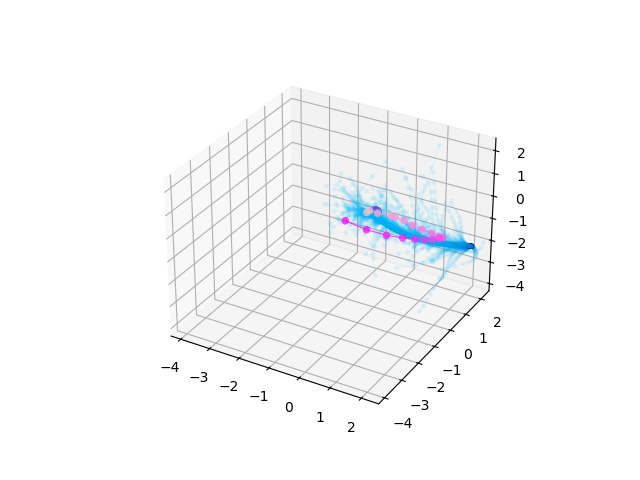

In [67]:
# Prepare initializations.
hidden_size = params['model']['rnn_config']['hidden_size']
num_inits = 150
h_0 = torch.randn(
    num_inits, 
    hidden_size, 
    device=local_device) * 1

# Prepare empty input.
input_size = params['data']['train']['transform'].ambient_dim
num_timesteps = 100
input = torch.zeros((num_inits, num_timesteps, input_size), device=local_device)

# Run forward pass in zeros input from different initializations.
_, hidden_random_init, _ = model.forward(input, h_0=h_0.unsqueeze(0))
hidden_random_init = hidden_random_init.to('cpu')

random_init_pcs_all, _, _, random_init_eigenvecs, _ = pca(
    hidden_random_init.reshape(-1, hidden_size), num_comps=3
)

fig_7 = plt.figure()
ax_7 = fig_7.add_subplot(projection='3d')
axis_limits = (
    random_init_pcs_all.min().detach().numpy(),
    random_init_pcs_all.max().detach().numpy(),
)
ax_7.set_xlim(axis_limits)
ax_7.set_ylim(axis_limits)
ax_7.set_zlim(axis_limits)

print(hidden_random_init.shape)

for i_init in range(num_inits):
    # PCs for current trajectory.
    pcs = hidden_random_init[i_init, :, :] @ random_init_eigenvecs

    _, axs_7 = plot_utils.plot_trajectory(
                pcs, 
                ax=ax_7,
                traj_linewidth=0.5,
                marker_size=12,
                alpha=0.1,
                set_box_aspect=False,
                uniform_axis_size=False,
                cmap=mcolors.LinearSegmentedColormap.from_list(
                    'deepsky_to_darkblue', 
                    [(0, 'deepskyblue'), (1, 'darkblue')]
                )
            )
    
axs_7.scatter(torch.tensor([0]), torch.tensor([0]), torch.tensor([0]), s=70, color='darkorchid')



_, axs_7 = plot_utils.plot_trajectory(
                hidden_test[batch_seq_idx, :hidden_test_lengths[batch_seq_idx], :] @ random_init_eigenvecs, 
                ax=axs_7,
                traj_linewidth=0.8,
                marker_size=30,
                alpha=0.75,
                set_box_aspect=False,
                uniform_axis_size=False,
                cmap=mcolors.LinearSegmentedColormap.from_list(
                    'pink_to_darkred', 
                    [(0, 'pink'), (1, 'fuchsia')]
                )
            )

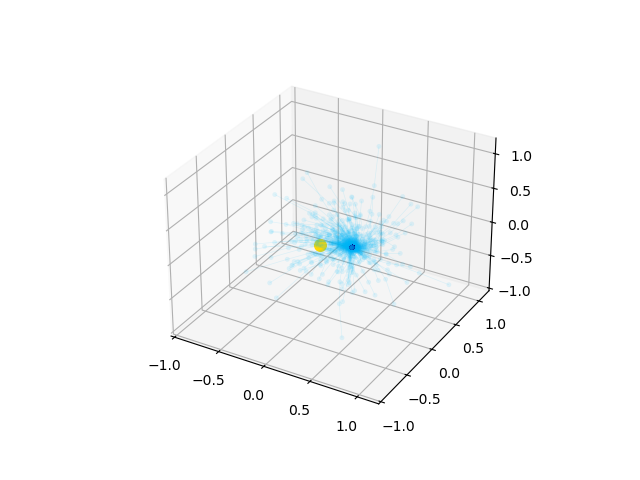

In [68]:
# Same as above cell but for newly initialized model.

# Prepare initializations.
hidden_size = params['model']['rnn_config']['hidden_size']
num_inits = 150
h_0 = torch.randn(
    num_inits, 
    hidden_size, 
    device=local_device) * 0.5

# Prepare empty input.
input_size = params['data']['train']['transform'].ambient_dim
num_timesteps = 100
input = torch.zeros((num_inits, num_timesteps, input_size), device=local_device)

# Run forward pass in zeros input from different initializations.
model_2 = AutoRNN(
    params['model']['input_network_config'],
    params['model']['rnn_config'],
    params['model']['readout_network_config'],
    rnn_type=rnn_type,
    tokens=sequences['train'].transform(
        torch.cat(
            (sequences['train'].special_tokens['count']['token'].unsqueeze(0), 
            sequences['train'].special_tokens['eos']['token'].unsqueeze(0)), 
            dim=0
        )
    ).to(local_device)
)
model_2.to(local_device)
_, hidden_random_init, _ = model_2.forward(input, h_0=h_0.unsqueeze(0))
hidden_random_init = hidden_random_init.to('cpu')

random_init_pcs_all, _, _, random_init_eigenvecs, _ = pca(
    hidden_random_init.reshape(-1, hidden_size), num_comps=3
)

fig_8 = plt.figure()
ax_8 = fig_8.add_subplot(projection='3d')
axis_limits = (
    random_init_pcs_all.min().detach().numpy(),
    random_init_pcs_all.max().detach().numpy(),
)
ax_8.set_xlim(axis_limits)
ax_8.set_ylim(axis_limits)
ax_8.set_zlim(axis_limits)

for i_init in range(num_inits):
    # PCs for current trajectory.
    pcs = hidden_random_init[i_init, :, :] @ random_init_eigenvecs

    _, axs_8 = plot_utils.plot_trajectory(
                pcs, 
                ax=ax_8,
                traj_linewidth=0.5,
                marker_size=12,
                alpha=0.1,
                set_box_aspect=False,
                uniform_axis_size=False,
                cmap=mcolors.LinearSegmentedColormap.from_list(
                    'deepsky_to_darkblue', 
                    [(0, 'deepskyblue'), (1, 'darkblue')]
                )
            )
    
axs_8.scatter(torch.tensor([0]), torch.tensor([0]), torch.tensor([0]), s=70, color='gold')



# _, axs_8 = plot_trajectory(
#                 hidden_test[batch_seq_idx, :hidden_test_lengths[batch_seq_idx], :] @ random_init_eigenvecs, 
#                 ax=axs_8,
#                 traj_linewidth=0.8,
#                 marker_size=30,
#                 alpha=0.75,
#                 set_box_aspect=False,
#                 uniform_axis_size=False,
#                 cmap=mcolors.LinearSegmentedColormap.from_list(
#                     'lightsky_to_dark_blue', 
#                     [(0, 'pink'), (1, 'darkred')]
#                 )
#             )

Ground truth: tensor([ 2, -1,  5,  4,  5,  4, -1,  4,  3,  0,  0,  0,  0,  0,  1]).
Generated from random init: tensor([[0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0,

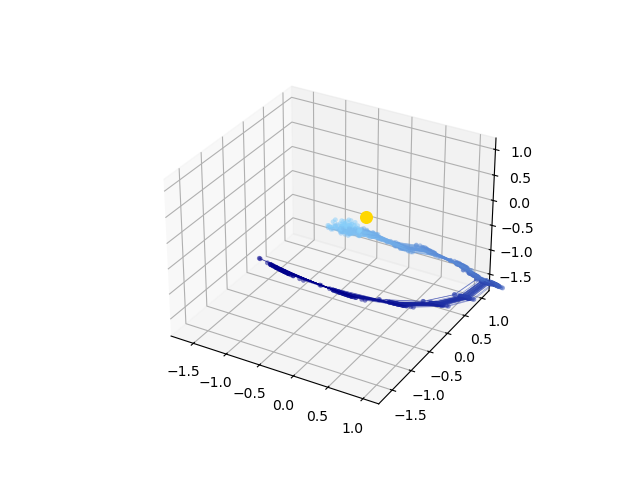

In [69]:
# For a single input sequence, try different initializations of the hidden state.

# Get one sequence.
seq_idx = 11
seq, labels, _, _, _ = sequences['test'][seq_idx]

# Repeat for multiple initializations.
num_inits = 50
seq = seq.repeat(num_inits, 1, 1)
seq = seq.to(local_device)
switch_ind = torch.where(labels == 3)[0].repeat(num_inits,)

# Prepare initializations.
hidden_size = params['model']['rnn_config']['hidden_size']
h_0 = torch.randn(
    1,
    num_inits, 
    hidden_size, 
    device=local_device
) * 0.075

generated, on_input, joined = model.generate(
    seq, input_lengths=switch_ind+1, 
    resp_lengths=seq.shape[1] - switch_ind - 1,
    h_0=h_0
)
generated = network_utils.move_to_device(generated, 'cpu')
on_input = network_utils.move_to_device(on_input, 'cpu')

# Join input demonstration phase and generated response hidden states for all 
# initializations on same sequence.
# hidden, _ = network_utils.join_demo_gen_resp(
#     on_input['hidden'],
#     on_input['input_lengths']-1, # -1 to exclude switch index, which will be included in the generated response
#     generated['hidden'],
#     generated['resp_lengths'],
# )
hidden, _ = joined['hidden']

print(f"Ground truth: {labels}.")
print(f"Generated from random init: {generated['labels']}.")

pcs_all, _, _, eigenvecs_all, _ = \
    pca(hidden.reshape(-1, hidden_size), num_comps=3)

fig_9 = plt.figure()
ax_9 = fig_9.add_subplot(projection='3d')
axis_limits = (
    pcs_all.min().detach().numpy(),
    pcs_all.max().detach().numpy(),
)
ax_9.set_xlim(axis_limits)
ax_9.set_ylim(axis_limits)
ax_9.set_zlim(axis_limits)

for i_init in range(num_inits):
    # PCs for current trajectory.
    pcs = hidden[i_init, :, :] @ eigenvecs_all

    _, axs_9 = plot_utils.plot_trajectory(
                pcs, 
                ax=ax_9,
                traj_linewidth=0.5,
                marker_size=12,
                alpha=0.5,
                set_box_aspect=False,
                uniform_axis_size=False
            )
    
axs_9.scatter(torch.tensor([0]), torch.tensor([0]), torch.tensor([0]), s=70, color='gold')
    


